# 02 — Gate Probabilities: the PD-style survival curve → investor return

**How the project-success probabilities were derived from public data — the credit-risk → infrastructure bridge — and how they drive the fund's investor IRR.**

Each development project must clear three *gates*; at each it either advances or stalls ('defaults'). The cumulative probability of success is the **product** of the gate probabilities — structurally a multi-period **probability-of-default (PD) / survival** curve.

| Gate | Public source | Metric |
|---|---|---|
| Planning approval | NSW/VIC/SA planning portals | approval rate + timeline |
| Grid connection | AEMO Connections Scorecard / KCI (sub-5 MW exemption may help) | connection success + duration |
| Reach sale | RTB buyer-pool depth + AEMO proposed→committed attrition | conversion rate |

*Educational; not investment advice. Boman figures are claims to verify. See `SOURCES.md` for LIVE vs BENCHMARK status.*

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from src import valuation_engine as ve
inp = ve.load_inputs(); s = ve.summary(inp)
plt.rcParams['figure.figsize'] = (7, 4)
NAVY, ACCENT, RED = '#1F3864', '#2E75B6', '#C00000'

## 1. The per-gate statistics (`data/processed/gate_stats.csv`)

In [2]:
gates = pd.read_csv('../data/processed/gate_stats.csv')
gates

,gate,probability,duration_years,source,as_at,status
0,planning_approval,0.8,1.25,NSW Planning Portal — approved vs refused/with...,2026-06-24,BENCHMARK
1,grid_connection,0.7,1.50,AEMO Connections Scorecard / KCI — connection ...,2026-06-24,BENCHMARK
2,reach_sale,0.8,0.50,AEMO proposed->committed attrition + active bu...,2026-06-24,BENCHMARK


## 2. Cumulative survival = product of gate probabilities

Python computes the *raw per-gate rates*; the Excel `Calc_Survival` tab builds the cumulative curve from them. This is the model's **independent** estimate.

In [3]:
sc = ve.survival_curve(inp)
print(f"Planning {sc['planning']:.0%}  ->  Connection {sc['connection']:.0%}  ->  Sale {sc['sale']:.0%}")
print(f"Independent cumulative P(success) = {sc['planning']:.2f} x {sc['connection']:.2f} x "
      f"{sc['sale']:.2f} = {sc['cumulative']:.1%}")

Planning 80%  ->  Connection 70%  ->  Sale 80%
Independent cumulative P(success) = 0.80 x 0.70 x 0.80 = 44.8%


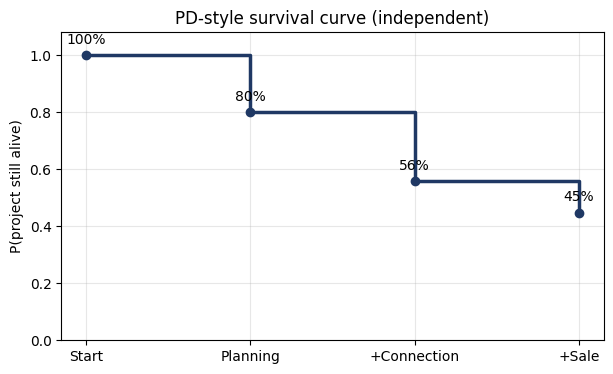

In [4]:
stages = ['Start', 'Planning', '+Connection', '+Sale']
surv = [1.0, sc['survival_after_planning'], sc['survival_after_connection'], sc['cumulative']]
fig, ax = plt.subplots()
ax.step(range(4), surv, where='post', color=NAVY, lw=2.5, marker='o')
[ax.annotate(f'{v:.0%}', (i, v), textcoords='offset points', xytext=(0, 8), ha='center') for i, v in enumerate(surv)]
ax.set_xticks(range(4)); ax.set_xticklabels(stages); ax.set_ylim(0, 1.08)
ax.set_ylabel('P(project still alive)'); ax.set_title('PD-style survival curve (independent)'); ax.grid(alpha=.3)
plt.show()

## 3. The headline DD finding — independent vs Boman's scenario success rates

The scenarios mirror Boman's deck (40 / 65 / 80%) so the rebuild is directly comparable. But the **independent** decomposition (~45%) lands **between Conservative (40%) and Base (65%)** — so **Boman's Base looks optimistic** unless the sub-5 MW exemption genuinely lifts small-distribution success.

In [5]:
rows = []
for cid, case in inp.scenarios.items():
    rows.append({'scenario': case['name'], 'success (Boman claim)': case['cum_success']})
df = pd.DataFrame(rows)
df['independent'] = sc['cumulative']
df['optimism gap'] = df['success (Boman claim)'] - sc['cumulative']
df

,scenario,success (Boman claim),independent,optimism gap
0,Conservative,0.40,0.448,-0.048
1,Base,0.65,0.448,0.202
2,Ideal,0.80,0.448,0.352


## 4. From survival curve to investor return — the funnel

The success rate is the **master driver**: `projects_started = target ÷ success`, so a lower success rate forces a bigger (more expensive) starting pipeline. Full dev cost is spent on delivered projects + a partial spend on the dropouts. After fees (entry + management + carry over the hurdle), this yields the **investor IRR & MOIC**.

In [6]:
rbs = ve.returns_by_scenario(inp)
rows = []
for name in ['Conservative', 'Base', 'Ideal']:
    m = rbs[name]
    rows.append({'scenario': name, 'success': f"{m['cum_success']:.0%}",
                 'started': round(m['projects_started']), 'dev cost $m': round(m['total_dev_cost'], 1),
                 'invested $m': round(m['invested_capital'], 1), 'gross $m': round(m['gross_proceeds'], 1),
                 'MOIC': round(m['moic'], 2), 'IRR': f"{m['irr']:.1%}"})
pd.DataFrame(rows)

,scenario,success,started,dev cost $m,invested $m,gross $m,MOIC,IRR
0,Conservative,40%,88,26.6,28.6,26.8,0.93,-3.3%
1,Base,65%,54,20.3,22.3,31.5,1.38,17.5%
2,Ideal,80%,44,18.2,20.2,36.2,1.68,29.7%


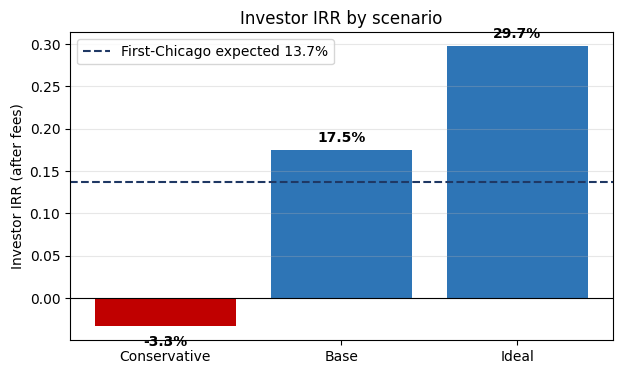

In [7]:
names = ['Conservative', 'Base', 'Ideal']
irrs = [rbs[n]['irr'] for n in names]
fig, ax = plt.subplots()
bars = ax.bar(names, irrs, color=[RED if v < 0 else ACCENT for v in irrs])
fc = ve.first_chicago(inp)
ax.axhline(0, color='black', lw=.8)
ax.axhline(fc['expected_irr'], color=NAVY, ls='--', lw=1.5,
           label=f"First-Chicago expected {fc['expected_irr']:.1%}")
[ax.annotate(f'{v:.1%}', (b.get_x()+b.get_width()/2, v), textcoords='offset points',
             xytext=(0, 6 if v >= 0 else -14), ha='center', fontweight='bold') for b, v in zip(bars, irrs)]
ax.set_ylabel('Investor IRR (after fees)'); ax.set_title('Investor IRR by scenario'); ax.legend(); ax.grid(axis='y', alpha=.3)
plt.show()

## 5. Probability-weighted (First-Chicago) expected return

In [8]:
fc = ve.first_chicago(inp)
print(f"First-Chicago expected investor IRR: {fc['expected_irr']:.1%}  (MOIC {fc['expected_moic']:.2f}x)")
print(f"Scenario IRR range: {fc['min_irr']:.1%} .. {fc['max_irr']:.1%}")
print(f"For comparison, Boman's claimed investor IRRs are 10.7% / 19.4% / 23.8%"
      f" — the independent rebuild is more conservative.")

First-Chicago expected investor IRR: 13.7%  (MOIC 1.31x)
Scenario IRR range: -3.3% .. 29.7%
For comparison, Boman's claimed investor IRRs are 10.7% / 19.4% / 23.8% — the independent rebuild is more conservative.


**Takeaway.** The survival curve is the analytical centrepiece: a transparent, public-data PD/survival model that feeds straight into the fund funnel and the investor IRR. The honest result — **independent success ~45% (below Boman's Base), a Conservative case that can lose capital, and an expected IRR below the manager's** — is exactly the credit-style scepticism the deal calls for. See the Excel `Calc_Survival`, `Calc_Fund` and `Returns` tabs.